In [1]:
!pip install uproot
import uproot

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 397.5/397.5 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 924.2/924.2 kB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 657.8/657.8 kB 27.5 MB/s eta 0:00:00


Viking.mac: /control/verbose 0

/control/execute /users/mw2304/geant4_apps/QEPET/build/quiet.mac

/process/em/QuantumEntanglement true

/run/numberOfThreads 1

'# To enable 3-gamma annihilations '#/process/em/setPositronAtRestModel OrePowellPolar'

'#/material/g4/ortoPositroniumFraction G4_AIR 1.0

'#/material/g4/ortoPositroniumFraction G4_WATER 1.0

'#/material/g4/ortoPositroniumFraction G4_BONE_COMPACT_ICRU 1.0

'# Activate/deactivate non-collinearity /QEPET/det/nonCollin false

/control/execute /users/mw2304/geant4_apps/QEPET/build/randomTissues.mac

/run/initialize

/control/execute /users/mw2304/geant4_apps/QEPET/build/fiveSphericalSources.mac

/run/beamOn 100000

In [2]:
import matplotlib.pyplot as plt

rootfile = uproot.open('FSStest.root')
print(rootfile.keys())

['NCS;1', 'PhantomSCS;1', 'ScannerSCS;1', 'PhantomSCS_ScannerSCS;1', 'PhantomDCS;1', 'ScannerDCS;1', 'PhantomSCS_ScannerDCS;1', 'PhantomDCS_ScannerSCS;1', 'PhantomDCS_ScannerDCS;1', 'MCS;1', 'Excluded;1']


In [3]:
tree = rootfile["NCS"]

print(tree.num_entries)

8239.0


In [4]:
tree = rootfile['NCS']
print(tree.keys())

['AnnihilX', 'AnnihilY', 'AnnihilZ', 'Gamma1_ScatterX', 'Gamma1_ScatterY', 'Gamma1_ScatterZ', 'Gamma1_Theta', 'Gamma1_HitE1', 'Gamma1_HitX1', 'Gamma1_HitY1', 'Gamma1_HitZ1', 'Gamma1_HitE2', 'Gamma1_HitX2', 'Gamma1_HitY2', 'Gamma1_HitZ2', 'Gamma2_ScatterX', 'Gamma2_ScatterY', 'Gamma2_ScatterZ', 'Gamma2_Theta', 'Gamma2_HitE1', 'Gamma2_HitX1', 'Gamma2_HitY1', 'Gamma2_HitZ1', 'Gamma2_HitE2', 'Gamma2_HitX2', 'Gamma2_HitY2', 'Gamma2_HitZ2', 'DeltaPhi']


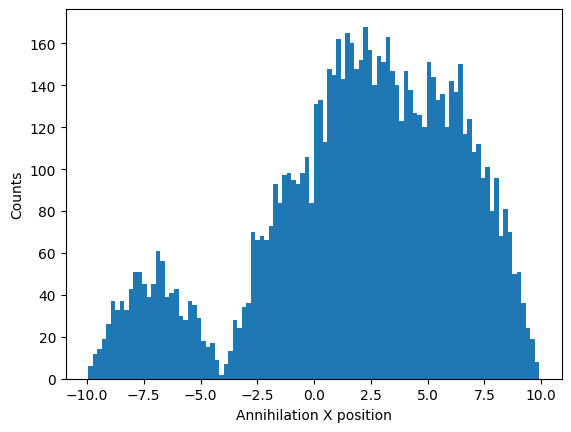

In [5]:
x = tree["AnnihilX"].array(library="np")
plt.hist(x, bins=100)
plt.xlabel("Annihilation X position")
plt.ylabel("Counts")
plt.show()

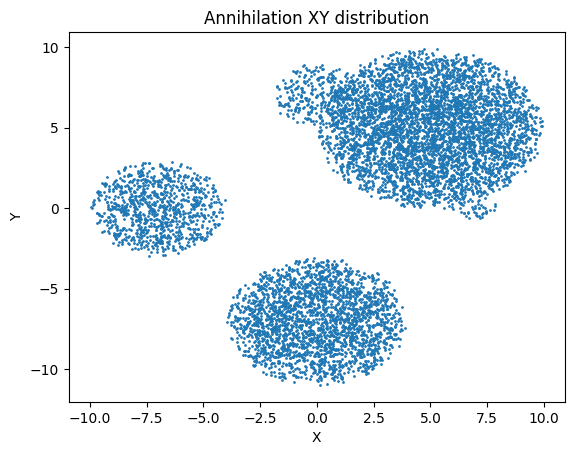

In [6]:
x = tree["AnnihilX"].array()
y = tree["AnnihilY"].array()

plt.scatter(x, y, s=1)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Annihilation XY distribution")
plt.show()

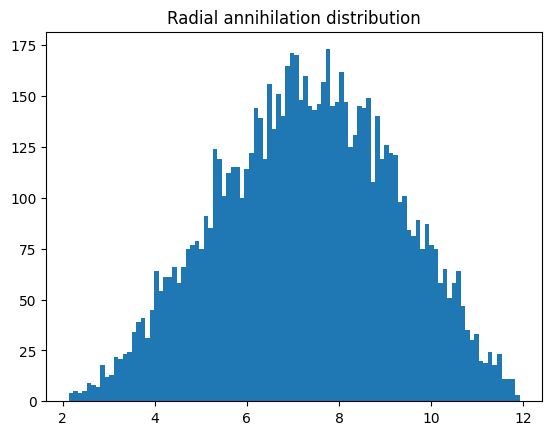

In [8]:
import numpy as np
r = np.sqrt(x**2 + y**2)

plt.hist(r, bins=100)
plt.title("Radial annihilation distribution")
plt.show()

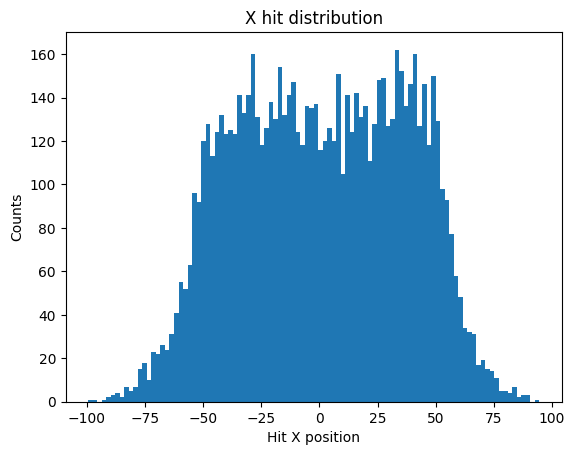

In [9]:
x = tree["Gamma1_HitX1"].array(library="np")

plt.hist(x, bins=100)
plt.xlabel("Hit X position")
plt.ylabel("Counts")
plt.title("X hit distribution")
plt.show()

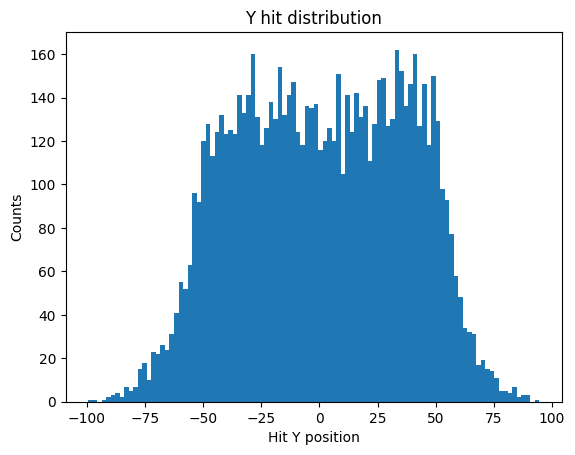

In [10]:
y = tree["Gamma1_HitY1"].array(library="np")

plt.hist(x, bins=100)
plt.xlabel("Hit Y position")
plt.ylabel("Counts")
plt.title("Y hit distribution")
plt.show()

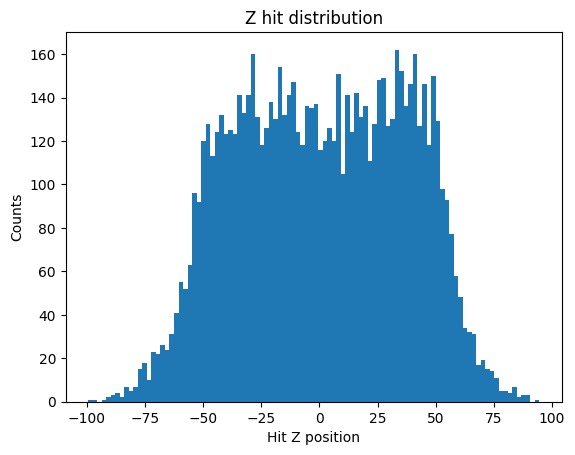

In [11]:
Z = tree["Gamma1_HitZ1"].array(library="np")

plt.hist(x, bins=100)
plt.xlabel("Hit Z position")
plt.ylabel("Counts")
plt.title("Z hit distribution")
plt.show()

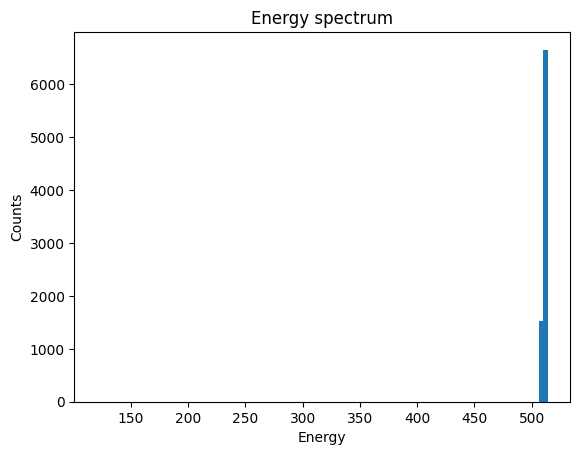

In [13]:
import uproot
import matplotlib.pyplot as plt

f = uproot.open("FSStest.root")
tree = f[list(f.keys())[0]]

energy = tree["Gamma1_HitE1"].array(library="np")

plt.hist(energy, bins=100)
plt.xlabel("Energy")
plt.ylabel("Counts")
plt.title("Energy spectrum")
plt.show()

In [14]:
f = uproot.open("FSStest.root")
tree = f["NCS"]

g1 = tree["Gamma1_Theta"].array(library="np")
g2 = tree["Gamma2_Theta"].array(library="np")

print(np.mean(g1))
print(np.mean(g2))
print(np.allclose(g1, g2))

0.0
0.0
True


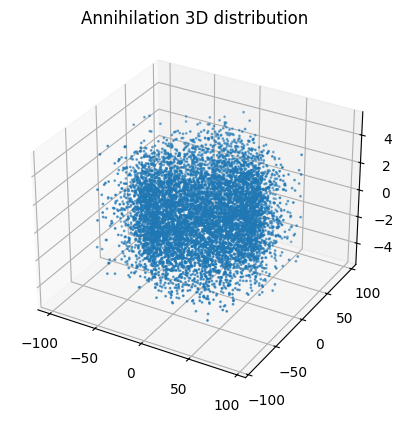

In [15]:
z = tree["AnnihilZ"].array(library="np")

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x, y, z, s=1)

ax.set_title("Annihilation 3D distribution")
plt.show()